In [1]:
from google.colab import drive
drive.mount('/gdrive')

ValueError: mount failed

In [ ]:
import pandas as pd
df = pd.read_csv('/gdrive/My Drive/dataStructure/data/pollution.csv')

In [ ]:
df.head()

,지역코드,시도명,시군구,acm_종별,위도,경도,오염물질,연배출량(kg/yr)
0,4139013200,경기도,시흥시,3종,37.346706,126.704952,구리화합물,0.297
1,4139013200,경기도,시흥시,3종,37.346706,126.704952,납화합물,0.112
2,4139013200,경기도,시흥시,3종,37.346706,126.704952,디클로로메탄,0.715
3,4139013200,경기도,시흥시,3종,37.346706,126.704952,먼지,140.479
4,4139013200,경기도,시흥시,3종,37.346706,126.704952,염화수소,5.493


In [ ]:
df.columns = ['location','loc1','loc2','acm','lat','long','pol','amount']
df.head()

,location,loc1,loc2,acm,lat,long,pol,amount
0,4139013200,경기도,시흥시,3종,37.346706,126.704952,구리화합물,0.297
1,4139013200,경기도,시흥시,3종,37.346706,126.704952,납화합물,0.112
2,4139013200,경기도,시흥시,3종,37.346706,126.704952,디클로로메탄,0.715
3,4139013200,경기도,시흥시,3종,37.346706,126.704952,먼지,140.479
4,4139013200,경기도,시흥시,3종,37.346706,126.704952,염화수소,5.493


In [ ]:
df.loc[pd.isnull(df['lat'])]

,location,loc1,loc2,acm,lat,long,pol,amount
11919,4122031026,경기도,평택시,3종,NaN,NaN,먼지,0.021
11920,4122031026,경기도,평택시,3종,NaN,NaN,아연화합물,0.001
11921,4122031026,경기도,평택시,3종,NaN,NaN,탄화수소(THC),0.027
30836,4719011300,경상북도,구미시,2종,NaN,NaN,구리화합물,0.452
30837,4719011300,경상북도,구미시,2종,NaN,NaN,납화합물,2.236
...,...,...,...,...,...,...,...,...
114075,4313033532,충청북도,충주시,1종,NaN,NaN,황산화물,0.000
114076,4313033532,충청북도,충주시,1종,NaN,NaN,먼지,24.019
114077,4313033532,충청북도,충주시,1종,NaN,NaN,질소산화물,458.429
114078,4313033532,충청북도,충주시,1종,NaN,NaN,황산화물,2.062


In [ ]:
df = df.dropna()

In [ ]:
df.loc1.value_counts()

loc1
경기도        21286
전라남도       16419
경상북도       13050
충청남도       12756
경상남도       11261
울산광역시      10165
충청북도        8072
전라북도        5712
인천광역시       3862
부산광역시       3267
강원도         2625
광주광역시       2309
대구광역시       1752
세종특별자치시     1157
대전광역시        977
서울특별시        461
제주특별자치도      218
Name: count, dtype: int64

In [ ]:
import duckdb
def dfsql(query):
   return duckdb.query(query).df()

In [ ]:
dfsql("select count(distinct pol) from df")

,count(DISTINCT pol)
0,46


In [ ]:
dfsql("select pol, sum(amount) as amt from df group by pol order by amt DESC")

,pol,amt
0,질소산화물,2.048824e+08
1,황산화물,8.038266e+07
2,일산화탄소,4.535852e+07
3,먼지,1.572240e+07
4,탄화수소(THC),1.068827e+07
5,암모니아,2.593628e+06
6,염화수소,2.548549e+06
7,페놀화합물,1.070005e+06
8,불소화합물,5.532962e+05
9,벤젠,4.422224e+05


In [ ]:
df_Nox = dfsql("select lat, long, amount from df where pol = '질소산화물' and amount > 0")

<Axes: >

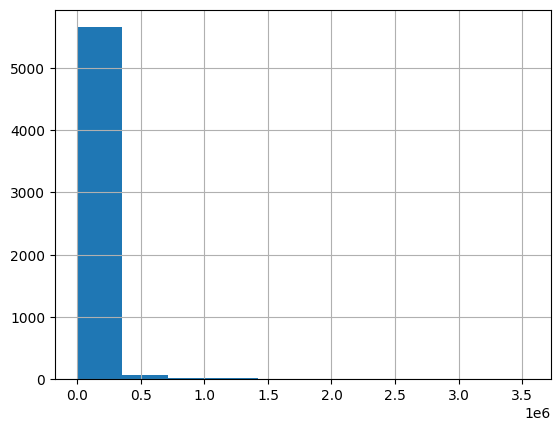

In [ ]:
df_Nox['amount'].hist()

<Axes: >

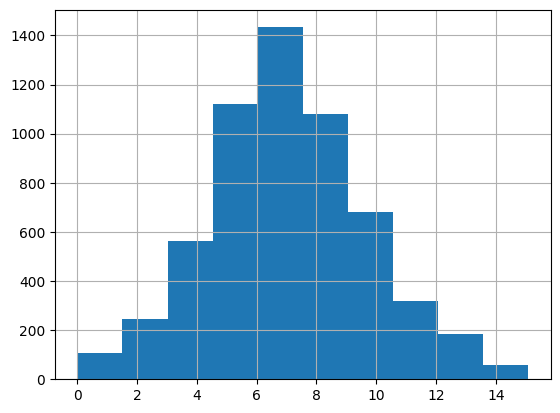

In [ ]:
import numpy as np
df_Nox['logAmt'] = np.log(df_Nox['amount']+1)
df_Nox['logAmt'].hist()

In [ ]:
df_Nox['amount'].describe()

count    5.787000e+03
mean     3.540390e+04
std      1.879156e+05
min      8.000000e-03
25%      2.078390e+02
50%      1.045334e+03
75%      5.932065e+03
max      3.549074e+06
Name: amount, dtype: float64

In [ ]:
import numpy as np
df['logAmt'] = np.log(df['amount']+1)
df['logAmt'].describe()

count    115349.000000
mean          2.823981
std           2.738949
min           0.000000
25%           0.088926
50%           2.320720
75%           4.798555
max          16.662727
Name: logAmt, dtype: float64

In [ ]:
#geojson파일을 json.load를 이용해 불러온다
import json
state_geo = '/gdrive/My Drive/dataStructure/data/sig.json'
state_geo2 = json.load(open(state_geo, encoding='utf-8'))

In [ ]:
center = df_Nox['lat'].mean(), df_Nox['long'].mean()

In [ ]:
df_Nox

,lat,long,amount,logAmt
0,35.141892,126.790244,10140.512,9.224392
1,35.143788,126.789558,58.841,4.091691
2,35.141859,126.790142,11502.089,9.350371
3,35.143942,126.788977,190.278,5.253728
4,35.144046,126.788739,12.825,2.626479
...,...,...,...,...
5782,36.737302,127.266756,679.702,6.523125
5783,36.888224,127.680174,1347.395,7.206670
5784,37.011895,126.560072,742.523,6.611400
5785,36.643014,127.331651,943.357,6.850504


In [ ]:
import folium
from folium import plugins
center = df_Nox['lat'].mean(), df_Nox['long'].mean()

#맵이 center에 위치하고 zoom 레벨은 11로 시작하는 맵 생성
pol_map = folium.Map(location=center, zoom_start=10)

folium.Marker(center,icon=folium.Icon('red', icon='star')).add_to(pol_map)

for i in range(len(df_Nox)):
    folium.CircleMarker([df_Nox.iloc[i][0], df_Nox.iloc[i][1]], popup=df_Nox.iloc[i][3],
                            radius = df_Nox.iloc[i][3] , color = 'blue').add_to(pol_map)

pol_map.save("result.html")

In [ ]:
heat_data = [[row['lat'],row['long']] for index, row in df_Nox.iterrows()]

In [ ]:
heat_data

[[35.141892, 126.790244],
 [35.143788, 126.789558],
 [35.141859, 126.790142],
 [35.143942, 126.788977],
 [35.144046, 126.788739],
 [35.14399, 126.788547],
 [35.144014, 126.788427],
 [35.141895, 126.790304],
 [35.144189, 126.788274],
 [35.311307, 127.202803],
 [35.310011, 127.204776],
 [35.31113, 127.202659],
 [35.312235, 127.203236],
 [36.978449, 126.852917],
 [36.978449, 126.852957],
 [36.854147, 126.453251],
 [36.853808, 126.451799],
 [36.853438, 126.450262],
 [36.128927, 127.142113],
 [36.148442, 128.435397],
 [36.150921, 128.437743],
 [36.150774, 128.4377],
 [36.148509, 128.435348],
 [36.148501, 128.435365],
 [36.149391, 128.435021],
 [36.148423, 128.435302],
 [37.508861, 126.889739],
 [35.500803, 129.312997],
 [35.502591, 129.34839],
 [35.513121, 129.351302],
 [35.510465, 129.354858],
 [35.509263, 129.354584],
 [35.500555, 129.345433],
 [35.514238, 129.351891],
 [35.496748, 129.35004],
 [35.507922, 129.352282],
 [35.502127, 129.346806],
 [35.502272, 129.350305],
 [35.500948, 129.3

In [ ]:
from folium.plugins import HeatMap
import folium
m = folium.Map(
    location = center,
    zoom_start = 10,
    titles = '배출구 위치'
)

HeatMap(heat_data).add_to(m)
m.save('heatmap.html')

In [ ]:
m

In [ ]:
df_copper = df.loc[df['pol'] == '구리화합물']

In [ ]:
import numpy as np
locations = df_copper[['lat','long']].values.tolist()
locations = np.array(locations)

In [ ]:
center = [37.44969402180274, 126.65414427564914] # 인하대
distances = []
for loc in locations:
    distances.append(np.sqrt(np.sum((loc - center)**2)))

indexes = np.argsort(np.array(distances))
print(indexes[:10])


[ 894  893 1843 1856 1855 1854 1896 1897  797  795]


In [ ]:
import sys
sys.setrecursionlimit(10000)

In [ ]:
from scipy import spatial
tree = spatial.KDTree(locations, leafsize=100)
_, nearChimley = tree.query(center, k=10)


In [ ]:
nearChimley

array([ 894,  893, 1843, 1856, 1855, 1854, 1896, 1897,  797,  795])

In [ ]:
center

[37.44969402180274, 126.65414427564914]

In [ ]:
import folium
from folium import plugins

#맵이 center에 위치하고 zoom 레벨은 11로 시작하는 맵 생성
pol_map = folium.Map(location=center, zoom_start=10)

folium.Marker(center,icon=folium.Icon('red', icon='star')).add_to(pol_map)

for i in range(len(locations)):
    if i in nearChimley:
        folium.CircleMarker([df_copper.iloc[i][4], df_copper.iloc[i][5]], popup=df_copper.iloc[i][7],
                            radius = df_copper.iloc[i][8] , color = 'red').add_to(pol_map)
    else:
        folium.CircleMarker([df_copper.iloc[i][4], df_copper.iloc[i][5]], popup=df_copper.iloc[i][7],
                            radius = df_copper.iloc[i][8] , color = 'blue').add_to(pol_map)

pol_map.save("result.html")

In [ ]:
pol_map

Output hidden; open in https://colab.research.google.com to view.